In [23]:
from pathlib import Path
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
PROJECT_ROOT = Path("../../").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "echo" / "echonet"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "echo" / "echonet"

RAW_VIDEOS_DIR = RAW_DIR / "Videos"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw EchoNet:", RAW_DIR)
print("Videos:", RAW_VIDEOS_DIR)
print("Processed:", PROCESSED_DIR)

Raw EchoNet: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\echo\echonet
Videos: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\echo\echonet\Videos
Processed: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\echo\echonet


In [25]:
filelist_path = RAW_DIR / "FileList.csv"
tracings_path = RAW_DIR / "VolumeTracings.csv"

required = {
    "FileList.csv": filelist_path,
    "VolumeTracings.csv": tracings_path,
    "Videos": RAW_VIDEOS_DIR,
}

for name, path in required.items():
    print(
        f"{name:20} : "
        f"{'FOUND' if path.exists() else 'MISSING'}"
    )

if not filelist_path.exists():
    raise FileNotFoundError(filelist_path)

if not RAW_VIDEOS_DIR.exists():
    raise FileNotFoundError(RAW_VIDEOS_DIR)

FileList.csv         : FOUND
VolumeTracings.csv   : FOUND
Videos               : FOUND


In [26]:
filelist = pd.read_csv(filelist_path)
tracings = pd.read_csv(tracings_path)

print("FileList:", filelist.shape)
print("VolumeTracings:", tracings.shape)

display(filelist.head())

FileList: (10030, 9)
VolumeTracings: (425010, 6)


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [27]:
print("FileList columns:")
print(filelist.columns.tolist())

print("\nVolumeTracings columns:")
print(tracings.columns.tolist())

FileList columns:
['FileName', 'EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS', 'NumberOfFrames', 'Split']

VolumeTracings columns:
['FileName', 'X1', 'Y1', 'X2', 'Y2', 'Frame']


In [28]:
filename_candidates = [
    "FileName",
    "Filename",
    "filename",
]

ef_candidates = [
    "EF",
    "ef",
]

filename_col = next(
    (col for col in filename_candidates if col in filelist.columns),
    None
)

ef_col = next(
    (col for col in ef_candidates if col in filelist.columns),
    None
)

if filename_col is None:
    raise KeyError(
        f"Could not find video filename column. "
        f"Available columns: {filelist.columns.tolist()}"
    )

if ef_col is None:
    raise KeyError(
        f"Could not find EF column. "
        f"Available columns: {filelist.columns.tolist()}"
    )

print("Filename column:", filename_col)
print("EF column:", ef_col)

Filename column: FileName
EF column: EF


In [29]:
echo = filelist.copy()

echo["video_name"] = (
    echo[filename_col]
    .astype(str)
    .str.strip()
)

echo["EF"] = pd.to_numeric(
    echo[ef_col],
    errors="coerce"
)

echo = echo.dropna(
    subset=["video_name", "EF"]
).copy()

print("Records with usable filename + EF:", len(echo))
display(
    echo[["video_name", "EF"]].head()
)

Records with usable filename + EF: 10030


,video_name,EF
0,0X100009310A3BD7FC,78.498406
1,0X1002E8FBACD08477,59.101988
2,0X1005D03EED19C65B,62.363798
3,0X10075961BC11C88E,54.545097
4,0X10094BA0A028EAC3,24.887742


In [30]:
video_extensions = {
    ".avi",
    ".mp4",
    ".mov",
    ".mkv",
}

video_files = [
    path
    for path in RAW_VIDEOS_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in video_extensions
]

print("Local video files:", len(video_files))

Local video files: 1530


In [31]:
video_map = {}

for path in video_files:
    stem = path.stem.strip().lower()

    if stem not in video_map:
        video_map[stem] = path

print("Unique local video IDs:", len(video_map))

Unique local video IDs: 1530


In [32]:
echo["video_stem"] = (
    echo["video_name"]
    .str.replace(r"\.[^.]+$", "", regex=True)
    .str.lower()
    .str.strip()
)

echo["video_path"] = echo["video_stem"].map(video_map)

echo["video_exists"] = echo["video_path"].notna()

matched = echo[echo["video_exists"]].copy()

print("Metadata records:", len(echo))
print("Matched videos:", len(matched))
print("Unmatched records:", (~echo["video_exists"]).sum())

print(
    "Match percentage:",
    f"{len(matched) / len(echo) * 100:.2f}%"
)

Metadata records: 10030
Matched videos: 1530
Unmatched records: 8500
Match percentage: 15.25%


In [33]:
display(
    matched[
        ["video_name", "EF", "video_path"]
    ].head(10)
)

,video_name,EF,video_path
0,0X100009310A3BD7FC,78.498406,D:\Programming\VS Code\Projects\CardioFusion-X...
1,0X1002E8FBACD08477,59.101988,D:\Programming\VS Code\Projects\CardioFusion-X...
2,0X1005D03EED19C65B,62.363798,D:\Programming\VS Code\Projects\CardioFusion-X...
3,0X10075961BC11C88E,54.545097,D:\Programming\VS Code\Projects\CardioFusion-X...
4,0X10094BA0A028EAC3,24.887742,D:\Programming\VS Code\Projects\CardioFusion-X...
5,0X100CF05D141FF143,55.951790,D:\Programming\VS Code\Projects\CardioFusion-X...
6,0X100E3B8D3280BEC5,36.573739,D:\Programming\VS Code\Projects\CardioFusion-X...
7,0X100E491B3CD58DE2,33.991745,D:\Programming\VS Code\Projects\CardioFusion-X...
8,0X100F044876B98F90,69.315252,D:\Programming\VS Code\Projects\CardioFusion-X...
9,0X101026B90DAE7E95,46.755194,D:\Programming\VS Code\Projects\CardioFusion-X...


In [34]:
print("EF missing:", matched["EF"].isna().sum())

print("\nEF summary:")
display(
    matched["EF"].describe().to_frame()
)

invalid_ef = (
    (matched["EF"] < 0)
    | (matched["EF"] > 100)
)

print("Invalid EF values:", invalid_ef.sum())

EF missing: 0

EF summary:


,EF
count,1530.000000
mean,56.283676
std,12.133747
min,6.907258
25%,52.533759
50%,59.417450
75%,64.278103
max,88.142061


Invalid EF values: 0


In [35]:
matched = matched[
    matched["EF"].between(0, 100)
].copy()

matched = matched.reset_index(drop=True)

print("Records after EF validation:", len(matched))

Records after EF validation: 1530


In [36]:
split_candidates = [
    "Split",
    "split",
    "SPLIT",
]

split_col = next(
    (col for col in split_candidates if col in matched.columns),
    None
)

if split_col is not None:
    print("Split column:", split_col)
    print(matched[split_col].value_counts(dropna=False))
else:
    print("No split column found.")

Split column: Split
Split
TRAIN    1144
VAL       204
TEST      182
Name: count, dtype: int64


In [37]:
if split_col is not None:

    matched["split"] = (
        matched[split_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    print(
        matched["split"]
        .value_counts(dropna=False)
    )

split
train    1144
val       204
test      182
Name: count, dtype: int64


In [38]:
sample_path = Path(
    matched.iloc[0]["video_path"]
)

cap = cv2.VideoCapture(str(sample_path))

if not cap.isOpened():
    raise RuntimeError(
        f"Could not open video: {sample_path}"
    )

frame_count = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)

cap.release()

print("Video:", sample_path.name)
print("Frames:", frame_count)
print("FPS:", fps)
print("Resolution:", width, "x", height)

Video: 0X100009310A3BD7FC.avi
Frames: 174
FPS: 50.0
Resolution: 112 x 112


In [39]:
NUM_FRAMES = 32
FRAME_STRIDE = 4

IMAGE_HEIGHT = 112
IMAGE_WIDTH = 112

OUTPUT_CHANNELS = 3

print("Frames:", NUM_FRAMES)
print("Stride:", FRAME_STRIDE)
print("Size:", IMAGE_HEIGHT, "x", IMAGE_WIDTH)
print("Channels:", OUTPUT_CHANNELS)

Frames: 32
Stride: 4
Size: 112 x 112
Channels: 3


In [40]:
def get_frame_indices(
    total_frames: int,
    num_frames: int = 32,
    stride: int = 4,
):
    required_frames = num_frames * stride

    if total_frames <= 0:
        return None

    if total_frames >= required_frames:
        max_start = total_frames - required_frames

        start = max_start // 2

        indices = (
            start
            + np.arange(num_frames) * stride
        )

        return indices.astype(int)

    # Video is shorter than the requested clip.
    # Use evenly spaced frames instead.
    indices = np.linspace(
        0,
        total_frames - 1,
        num_frames
    )

    return np.round(indices).astype(int)

In [41]:
sample_indices = get_frame_indices(
    frame_count,
    NUM_FRAMES,
    FRAME_STRIDE
)

print("Frame indices:")
print(sample_indices)

print("\nNumber of sampled frames:")
print(len(sample_indices))

Frame indices:
[ 23  27  31  35  39  43  47  51  55  59  63  67  71  75  79  83  87  91
  95  99 103 107 111 115 119 123 127 131 135 139 143 147]

Number of sampled frames:
32


In [42]:
def preprocess_frame(
    frame,
    height=112,
    width=112,
):
    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    resized = cv2.resize(
        gray,
        (width, height),
        interpolation=cv2.INTER_AREA
    )

    rgb = np.stack(
        [resized, resized, resized],
        axis=-1
    )

    return rgb.astype(np.uint8)

In [43]:
cap = cv2.VideoCapture(
    str(sample_path)
)

cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    int(sample_indices[0])
)

ret, frame = cap.read()

cap.release()

if not ret:
    raise RuntimeError(
        "Could not read sample frame."
    )

processed_frame = preprocess_frame(
    frame,
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)

print("Original frame shape:", frame.shape)
print("Processed frame shape:", processed_frame.shape)
print("Processed dtype:", processed_frame.dtype)

Original frame shape: (112, 112, 3)
Processed frame shape: (112, 112, 3)
Processed dtype: uint8


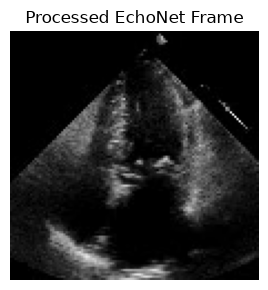

In [46]:
plt.figure(figsize=(4, 3))

plt.imshow(processed_frame)

plt.axis("off")
plt.title("Processed EchoNet Frame")

plt.tight_layout()
plt.show()

In [47]:
def inspect_video(path):
    cap = cv2.VideoCapture(str(path))

    if not cap.isOpened():
        return None

    frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    fps = float(
        cap.get(cv2.CAP_PROP_FPS)
    )

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    cap.release()

    return {
        "frame_count": frames,
        "fps": fps,
        "width": width,
        "height": height,
    }

In [48]:
video_metadata = []

for i, row in matched.iterrows():

    info = inspect_video(
        row["video_path"]
    )

    if info is None:
        continue

    indices = get_frame_indices(
        info["frame_count"],
        NUM_FRAMES,
        FRAME_STRIDE
    )

    video_metadata.append({
        "video_name": row["video_name"],
        "video_path": str(
            Path(row["video_path"]).relative_to(PROJECT_ROOT)
        ),
        "EF": float(row["EF"]),
        "split": row.get("split", "unknown"),
        "frame_count": info["frame_count"],
        "fps": info["fps"],
        "width": info["width"],
        "height": info["height"],
        "frame_indices": json.dumps(
            indices.tolist()
        ),
    })

    if (i + 1) % 100 == 0:
        print(f"Processed metadata: {i + 1}")

Processed metadata: 100
Processed metadata: 200
Processed metadata: 300
Processed metadata: 400
Processed metadata: 500
Processed metadata: 600
Processed metadata: 700
Processed metadata: 800
Processed metadata: 900
Processed metadata: 1000
Processed metadata: 1100
Processed metadata: 1200
Processed metadata: 1300
Processed metadata: 1400
Processed metadata: 1500


In [49]:
echo_manifest = pd.DataFrame(
    video_metadata
)

print("Final manifest shape:")
print(echo_manifest.shape)

display(
    echo_manifest.head()
)

Final manifest shape:
(1530, 9)


,video_name,video_path,EF,split,frame_count,fps,width,height,frame_indices
0,0X100009310A3BD7FC,data\raw\echo\echonet\Videos\0X100009310A3BD7F...,78.498406,val,174,50.0,112,112,"[23, 27, 31, 35, 39, 43, 47, 51, 55, 59, 63, 6..."
1,0X1002E8FBACD08477,data\raw\echo\echonet\Videos\0X1002E8FBACD0847...,59.101988,train,215,50.0,112,112,"[43, 47, 51, 55, 59, 63, 67, 71, 75, 79, 83, 8..."
2,0X1005D03EED19C65B,data\raw\echo\echonet\Videos\0X1005D03EED19C65...,62.363798,train,104,50.0,112,112,"[0, 3, 7, 10, 13, 17, 20, 23, 27, 30, 33, 37, ..."
3,0X10075961BC11C88E,data\raw\echo\echonet\Videos\0X10075961BC11C88...,54.545097,train,122,55.0,112,112,"[0, 4, 8, 12, 16, 20, 23, 27, 31, 35, 39, 43, ..."
4,0X10094BA0A028EAC3,data\raw\echo\echonet\Videos\0X10094BA0A028EAC...,24.887742,val,207,52.0,112,112,"[39, 43, 47, 51, 55, 59, 63, 67, 71, 75, 79, 8..."


In [50]:
print(
    "Missing EF:",
    echo_manifest["EF"].isna().sum()
)

print(
    "Missing frame count:",
    echo_manifest["frame_count"].isna().sum()
)

print(
    "Videos with < 1 frame:",
    (echo_manifest["frame_count"] < 1).sum()
)

print(
    "Missing paths:",
    echo_manifest["video_path"].isna().sum()
)

print("\nSplit distribution:")
print(
    echo_manifest["split"]
    .value_counts(dropna=False)
)

Missing EF: 0
Missing frame count: 0
Videos with < 1 frame: 0
Missing paths: 0

Split distribution:
split
train    1144
val       204
test      182
Name: count, dtype: int64


,EF
count,1530.000000
mean,56.283676
std,12.133747
min,6.907258
25%,52.533759
50%,59.417450
75%,64.278103
max,88.142061


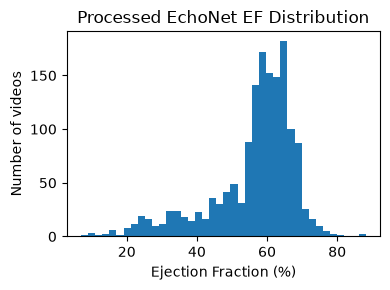

In [53]:
display(
    echo_manifest["EF"].describe().to_frame()
)

plt.figure(figsize=(4, 3))

plt.hist(
    echo_manifest["EF"],
    bins=40
)

plt.xlabel("Ejection Fraction (%)")
plt.ylabel("Number of videos")
plt.title("Processed EchoNet EF Distribution")

plt.tight_layout()
plt.show()

In [54]:
echo_manifest["lv_dysfunction"] = (
    echo_manifest["EF"] < 50
).astype(int)

echo_manifest["reduced_lvef"] = (
    echo_manifest["EF"] < 50
).astype(int)

echo_manifest["hfref"] = (
    echo_manifest["EF"] < 40
).astype(int)

display(
    echo_manifest[
        [
            "EF",
            "lv_dysfunction",
            "reduced_lvef",
            "hfref",
        ]
    ].head()
)

,EF,lv_dysfunction,reduced_lvef,hfref
0,78.498406,0,0,0
1,59.101988,0,0,0
2,62.363798,0,0,0
3,54.545097,0,0,0
4,24.887742,1,1,1


In [55]:
derived_summary = pd.DataFrame({
    "LV dysfunction (EF < 50%)": [
        echo_manifest["lv_dysfunction"].sum()
    ],
    "Reduced LVEF (EF < 50%)": [
        echo_manifest["reduced_lvef"].sum()
    ],
    "HFrEF (EF < 40%)": [
        echo_manifest["hfref"].sum()
    ],
})

display(derived_summary)

,LV dysfunction (EF < 50%),Reduced LVEF (EF < 50%),HFrEF (EF < 40%)
0,325,325,176


In [56]:
manifest_path = (
    PROCESSED_DIR / "echonet_manifest.csv"
)

echo_manifest.to_csv(
    manifest_path,
    index=False
)

print("Saved:")
print(manifest_path)

Saved:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\echo\echonet\echonet_manifest.csv


In [57]:
preprocessing_config = {
    "dataset": "EchoNet-Dynamic",
    "num_frames": NUM_FRAMES,
    "frame_stride": FRAME_STRIDE,
    "height": IMAGE_HEIGHT,
    "width": IMAGE_WIDTH,
    "channels": OUTPUT_CHANNELS,
    "grayscale_to_three_channel": True,
    "target": "EF",
    "target_type": "continuous_regression",
    "lv_dysfunction_threshold": 50.0,
    "hfref_threshold": 40.0,
}

config_path = (
    PROCESSED_DIR /
    "preprocessing_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing_config,
        f,
        indent=2
    )

print("Saved:")
print(config_path)

Saved:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\echo\echonet\preprocessing_config.json


In [58]:
print("======================================")
print("EchoNet preprocessing complete")
print("======================================")

print(f"Matched videos : {len(echo_manifest):,}")
print(
    f"EF mean        : "
    f"{echo_manifest['EF'].mean():.2f}%"
)
print(
    f"EF std         : "
    f"{echo_manifest['EF'].std():.2f}%"
)

print(
    f"EF < 50%       : "
    f"{echo_manifest['lv_dysfunction'].sum():,}"
)

print(
    f"EF < 40%       : "
    f"{echo_manifest['hfref'].sum():,}"
)

print(
    f"Manifest       : "
    f"{manifest_path}"
)

EchoNet preprocessing complete
Matched videos : 1,530
EF mean        : 56.28%
EF std         : 12.13%
EF < 50%       : 325
EF < 40%       : 176
Manifest       : D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\echo\echonet\echonet_manifest.csv
